# Aufgabe 3
In Aufgabe 3 betrachten wir einen Serineschwingkreis, gemessen wurde wieder die Transferfunktion $|U_R/U_0|$ und Phasenverschiebung $\theta$

In der Aufgbabe sollen wie in der nachfolgenden das Wiederstandsverhältnis $r$, die Dämpfungskonstante $\delta$ und die Resonanzfrequenz $f_0$ ermittelt werden, welches wie folgt gegeben wird.
$$r = R_d/(R_d + R_{sp})$$

![Schaltkreis für die 3. Aufgabe](./figures/Abbildung3.png)


=== RLC an R (UR/U0) – Phase gemessen als U0 rel. UR (Vorzeichen gedreht) ===
Modell A: L=0.98 mH, C=236 nF,  f0≈10465.3 Hz
  RMSE Betrag ≈ 0.41 dB,  RMSE Phase ≈ 28.96 °
Modell B (Fit): L=0.77 mH, C=243 nF,  f0≈11606.9 Hz
  RMSE Betrag ≈ 0.39 dB,  RMSE Phase ≈ 28.88 °


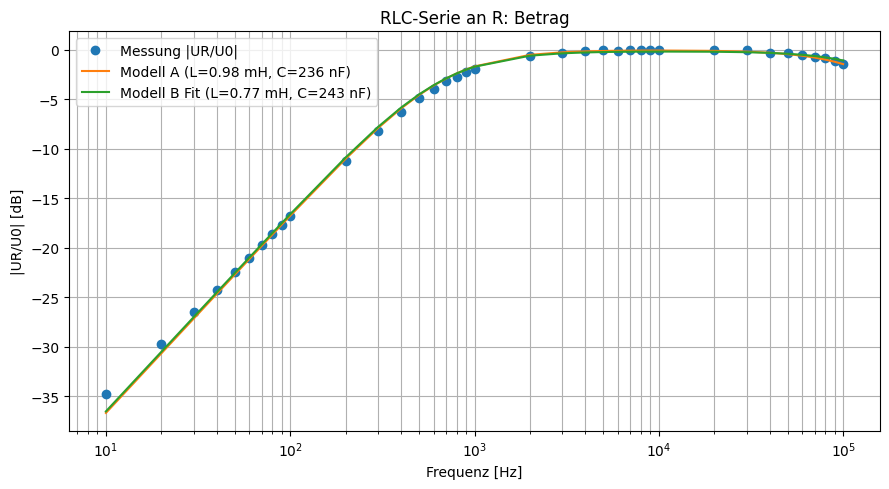

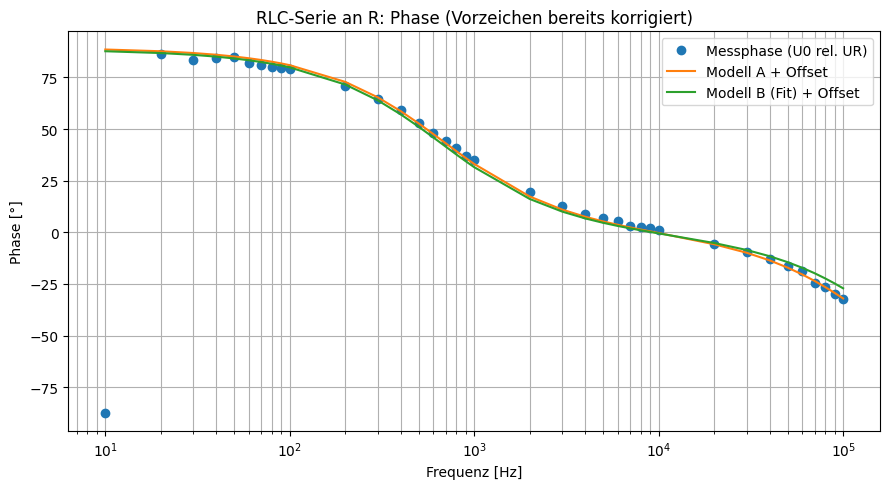

In [1]:
# ==== Aufgabe 3: Serie-RLC an R (UR/U0) – mit „umgedrehter“ gemessener Phase ====
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# -------- Parameter --------
R = 1000.0
CSV_PATH = "Messwerte/Aufgabe3.csv"  # bei dir anpassen
# grobe Erwartungen aus A1/A2 (nur für Modell A)
L_guess = 0.98e-3   # H
C_guess = 236e-9    # F

# -------- Helpers --------
def wrap_pm180(d): return ((d + 180.0) % 360.0) - 180.0
def mag2db(x):     return 20*np.log10(np.clip(x, 1e-20, None))
def circ_offset(a_deg, b_deg):
    diff = np.deg2rad(a_deg - b_deg)
    return np.rad2deg(np.arctan2(np.mean(np.sin(diff)), np.mean(np.cos(diff))))
def phase_rmse(a,b): return float(np.sqrt(np.mean(wrap_pm180(a-b)**2)))

def H_R_RLC(w, R, L, C):
    # Serie-RLC, Spannung am R relativ zu U0:
    # Z_total = R + j(ωL − 1/(ωC)),  H_R = R / Z_total
    X = w*L - 1.0/(w*C)
    Z = R + 1j*X
    H = R / Z
    return np.abs(H), np.degrees(np.angle(H))  # |UR/U0|,  φ(UR rel. U0)

def best_gain(meas, model):
    num = np.sum(meas*model); den = np.sum(model*model) + 1e-20
    return max(num/den, 1e-12)

# -------- Daten laden --------
df = pd.read_csv(CSV_PATH)
col_f  = next(c for c in df.columns if "Freq"  in c or "freq"  in c or "Frequ" in c)
col_u0 = next(c for c in df.columns if "U_0"  in c or "U0"   in c)
col_ur = next(c for c in df.columns if "U_R"  in c or "UR"   in c)
col_th = next(c for c in df.columns if "theta" in c or "Theta" in c or "phase" in c or "Phase" in c)

f = df[col_f].to_numpy(float)
U0 = df[col_u0].to_numpy(float)
UR = df[col_ur].to_numpy(float)
w  = 2*np.pi*f

# >>> WICHTIG: Du hast die Phase „anders herum“ gemessen:
# Messgerät: φ_meas_raw = φ(U0 rel. UR).
# Modell:    φ_model    = φ(UR rel. U0).
# Für den Vergleich drehen wir das Vorzeichen:
phi_meas = wrap_pm180(-df[col_th].to_numpy(float))
mag_meas = np.clip(UR/U0, 1e-12, None)

# -------- Modell A: feste L,C (aus A1/A2) --------
magA, phiA0 = H_R_RLC(w, R, L_guess, C_guess)
gainA = best_gain(mag_meas, magA)
phi0A = circ_offset(phi_meas, phiA0)     # nur Konstant-Offset, kein Vorzeichenflip mehr nötig
phiA  = phiA0 + phi0A
rmseA_mag = float(np.sqrt(np.mean((mag2db(mag_meas)-mag2db(gainA*magA))**2)))
rmseA_phi = phase_rmse(phi_meas, phiA)
f0A = 1.0/(2*np.pi*np.sqrt(L_guess*C_guess))

# -------- Modell B: Fit von L und C (robust; Betrag trägt die Physik) --------
L_vals = np.logspace(np.log10(0.2e-3), np.log10(5e-3), 120)
C_vals = np.logspace(np.log10(100e-9), np.log10(600e-9), 120)
best = None
for L in L_vals:
    for C in C_vals:
        magM, phiM0 = H_R_RLC(w, R, L, C)
        g = best_gain(mag_meas, magM)
        e_mag = float(np.sqrt(np.mean((mag2db(mag_meas)-mag2db(g*magM))**2)))
        # Phase: nur Konstant-Offset (Vorzeichen schon korrigiert)
        phi0 = circ_offset(phi_meas, phiM0)
        phiM = phiM0 + phi0
        e_phi = phase_rmse(phi_meas, phiM)
        # Leichte Gewichtung: Betrag dominiert, Phase hilft nur zur Feinanpassung
        err = e_mag + 0.25*e_phi
        if best is None or err < best["err"]:
            best = dict(L=L, C=C, gain=g, phi=phiM, mag=g*magM,
                        e_mag=e_mag, e_phi=e_phi, err=err)

L_fit, C_fit = best["L"], best["C"]
f0B = 1.0/(2*np.pi*np.sqrt(L_fit*C_fit))

print("=== RLC an R (UR/U0) – Phase gemessen als U0 rel. UR (Vorzeichen gedreht) ===")
print(f"Modell A: L={L_guess*1e3:.2f} mH, C={C_guess*1e9:.0f} nF,  f0≈{f0A:.1f} Hz")
print(f"  RMSE Betrag ≈ {rmseA_mag:.2f} dB,  RMSE Phase ≈ {rmseA_phi:.2f} °")
print(f"Modell B (Fit): L={L_fit*1e3:.2f} mH, C={C_fit*1e9:.0f} nF,  f0≈{f0B:.1f} Hz")
print(f"  RMSE Betrag ≈ {best['e_mag']:.2f} dB,  RMSE Phase ≈ {best['e_phi']:.2f} °")

# -------- Plots --------
plt.figure(figsize=(9,5))
plt.xscale("log")
plt.plot(f, mag2db(mag_meas), marker="o", linestyle="none", label="Messung |UR/U0|")
plt.plot(f, mag2db(gainA*magA), label=f"Modell A (L={L_guess*1e3:.2f} mH, C={C_guess*1e9:.0f} nF)")
plt.plot(f, mag2db(best['mag']),  label=f"Modell B Fit (L={L_fit*1e3:.2f} mH, C={C_fit*1e9:.0f} nF)")
plt.xlabel("Frequenz [Hz]"); plt.ylabel("|UR/U0| [dB]")
plt.title("RLC-Serie an R: Betrag")
plt.grid(True, which="both"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,5))
plt.xscale("log")
plt.plot(f, phi_meas, marker="o", linestyle="none", label="Messphase (U0 rel. UR)")
plt.plot(f, phiA, label="Modell A + Offset")
plt.plot(f, best['phi'], label="Modell B (Fit) + Offset")
plt.xlabel("Frequenz [Hz]"); plt.ylabel("Phase [°]")
plt.title("RLC-Serie an R: Phase (Vorzeichen bereits korrigiert)")
plt.grid(True, which="both"); plt.legend(); plt.tight_layout(); plt.show()
